In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle

In [ ]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 48 (delta 3), reused 15 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (48/48), 162.58 MiB | 19.07 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (25/25), done.
Filtering content: 100% (12/12), 851.90 MiB | 36.54 MiB/s, done.
/content/PRMLProject


In [ ]:
def unpickle(file):
    with open(file, 'rb') as f:
        return pickle.load(f)

In [ ]:
X_train_knn_pca_hog=unpickle("PreProcessedData/TrainFeaturesPCA_HoG.pkl")
print(X_train_knn_pca_hog.shape)
y_train=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train.shape)
X_test_knn_pca_hog=unpickle("PreProcessedData/TestFeaturesPCA_HoG.pkl")
y_test=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 324)
(50000,)


In [ ]:
# Flattening the image
X_train_knn_pca_hog = X_train_knn_pca_hog.reshape(50000, -1)
X_test_knn_pca_hog = X_test_knn_pca_hog.reshape(10000, -1)

print(X_train_knn_pca_hog.shape)
print(X_test_knn_pca_hog.shape)

(50000, 324)
(10000, 324)


Writing our own KNN Implementation

In [ ]:
import numpy as np
from collections import Counter

def find_knn(k=7, X_train=X_train_knn_pca_hog, X_test=X_test_knn_pca_hog, y_train=y_train, y_test=y_test):
    correct = 0
    results = []

    for idx, test_sample in enumerate(tqdm(X_test)):
        # Compute distances in a vectorized way
        distances = np.linalg.norm(X_train - test_sample, axis=1)

        # Get indices of k smallest distances
        k_nearest_indices = np.argsort(distances)[:k]

        # Get labels of k nearest neighbors
        k_labels = y_train[k_nearest_indices]

        # Majority vote for classification
        predicted_label = Counter(k_labels).most_common(1)[0][0]
        results.append(predicted_label)

        # Accuracy calculation
        if predicted_label == y_test[idx]:
            correct += 1

    return results, correct / len(X_test)

In [ ]:
results,accuracy = find_knn()

100%|██████████| 10000/10000 [19:58<00:00,  8.35it/s]


In [ ]:
accuracy

0.485

Printing Confusion Matrix fot our  own KNN Implementation

100%|██████████| 10000/10000 [20:06<00:00,  8.29it/s]


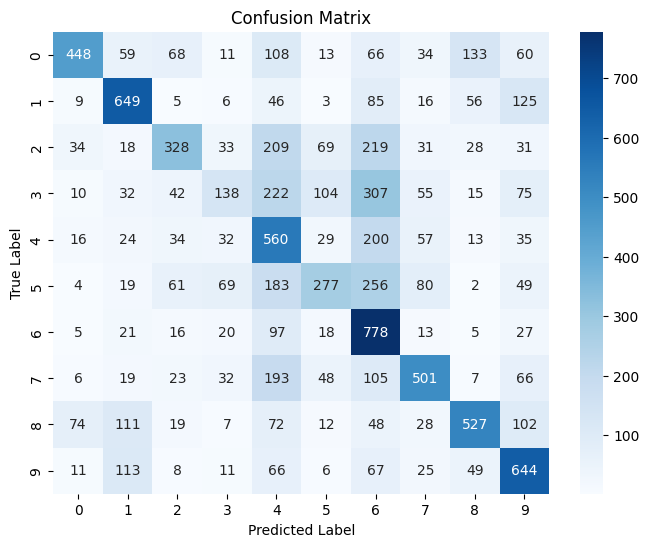

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

predictions, accuracy = find_knn()

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, predictions)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

using SkLearn Library with Euclidean as the distance metric

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def find_knn1(k=7, X_train=X_train_knn_pca_hog, X_test=X_test_knn_pca_hog, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

Accuracy: 0.4817
Confusion Matrix:
 [[488  67  71  16 107  15  55  20 116  45]
 [ 16 680   7   5  44   3  88  10  44 103]
 [ 51  22 369  38 225  62 169  20  22  22]
 [ 16  41  56 173 253  98 265  36  10  52]
 [ 25  34  48  42 578  24 173  43  10  23]
 [  9  26  92  92 211 257 228  51   1  33]
 [ 10  28  25  26 113  15 750   9   4  20]
 [ 14  28  38  48 224  49  99 447   4  49]
 [110 139  28   9  73  14  41  24 486  76]
 [ 22 142  12  12  84   7  68  23  41 589]]


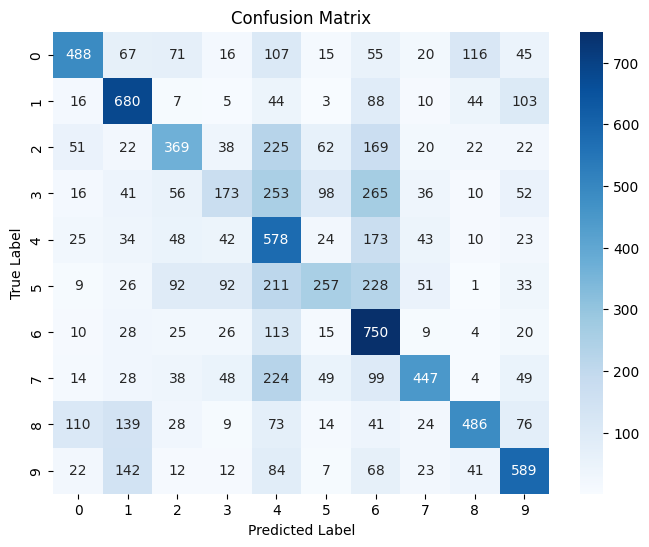

In [ ]:
find_knn1()

using SkLearn Library with Manhattan as the distance metric

Accuracy: 0.5175
Confusion Matrix:
 [[593  48  62  21  72  11  37  19 113  24]
 [ 31 721  13   3  27   1  48   8  53  95]
 [ 83  31 418  48 139  74 135  22  29  21]
 [ 42  57  99 209 181 113 170  55  11  63]
 [ 41  35  76  36 523  39 143  61  18  28]
 [ 14  31  92 111 154 335 158  54   8  43]
 [ 17  46  36  33  91  32 701  12   6  26]
 [ 26  26  53  52 164  65  59 501   5  49]
 [123 118  21   7  45   8  21  18 582  57]
 [ 38 137  19  13  57   8  49  32  55 592]]


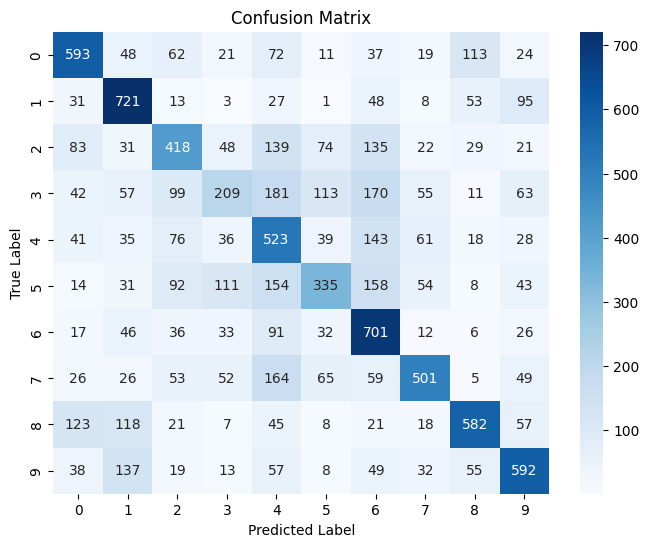

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def find_knn2(k=7, X_train=X_train_knn_pca_hog, X_test=X_test_knn_pca_hog, y_train=y_train, y_test=y_test):
    # Initialize k-NN classifier with Manhattan distance
    knn = KNeighborsClassifier(n_neighbors=k, metric='manhattan')

    # Train the model
    knn.fit(X_train, y_train)

    # Predict on test data
    y_pred = knn.predict(X_test)

    # Compute accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Compute confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

    return accuracy

accuracy = find_knn2()


using SkLearn Library with Canberra as the distance metric

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def find_knn3(k=7, X_train=X_train_knn_pca_hog, X_test=X_test_knn_pca_hog, y_train=y_train, y_test=y_test):
    # Initializing k-NN classifier with Canberra distance metric
    knn = KNeighborsClassifier(n_neighbors=k, metric='canberra')

    # Training the model
    knn.fit(X_train, y_train)

    # Prediction on test data
    y_pred = knn.predict(X_test)

    #computing accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Computing confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()



Accuracy: 0.4115
Confusion Matrix:
 [[423  63  60  14 147  17 114  29  77  56]
 [ 18 470   7   7  96   2 224  11  30 135]
 [ 44  18 271  21 237  56 302  16  12  23]
 [ 11  23  54 111 264  62 380  26   6  63]
 [  7  14  35  30 592  11 261  24   5  21]
 [ 12  10  38  73 273 181 332  38   4  39]
 [  4  10  16  19 116   6 800   6   1  22]
 [  6  21  35  28 300  36 189 341   3  41]
 [ 78 131  31  11 141  11  92  20 381 104]
 [ 15  68  13  10 135   8 160  30  16 545]]


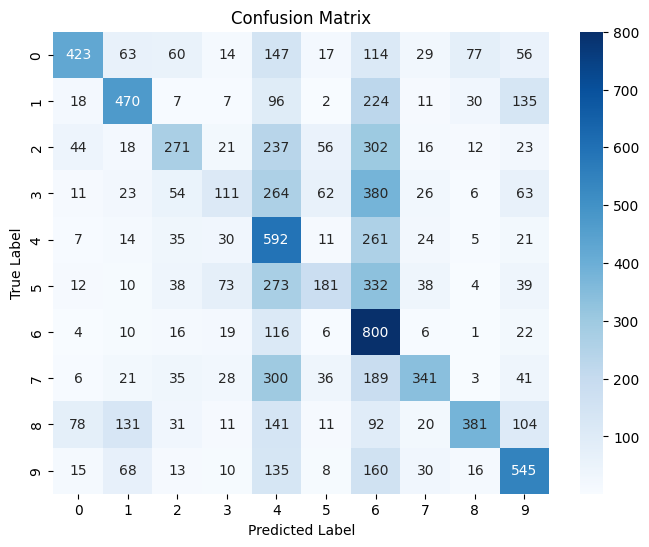

In [ ]:
find_knn3()

using SkLearn Library with Bray Curtis as the distance metric

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def find_knn4(k=7, X_train=X_train_knn_pca_hog, X_test=X_test_knn_pca_hog, y_train=y_train, y_test=y_test):
    # Initializing k-NN classifier with Bray-Curtis distance metric
    knn = KNeighborsClassifier(n_neighbors=k, metric='braycurtis')

    # Training the model
    knn.fit(X_train, y_train)

    # Predicting on test data
    y_pred = knn.predict(X_test)

    # Computing accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    # Computing confusion matrix
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", conf_matrix)

    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()



Accuracy: 0.4924
Confusion Matrix:
 [[502  61  60  13 112  15  59  31 104  43]
 [ 14 678   6   4  48   2  98  10  34 106]
 [ 56  24 345  39 220  74 181  22  16  23]
 [ 19  37  59 164 224  99 278  45   9  66]
 [ 18  26  46  28 578  20 190  49  10  35]
 [  8  20  50  91 207 291 228  58   4  43]
 [  3  32  16  17 100  24 771   8   5  24]
 [ 14  23  49  42 222  51  81 451   5  62]
 [ 80 130  23   7  80  10  44  20 516  90]
 [ 16 107   6   8  87   6  76  29  37 628]]


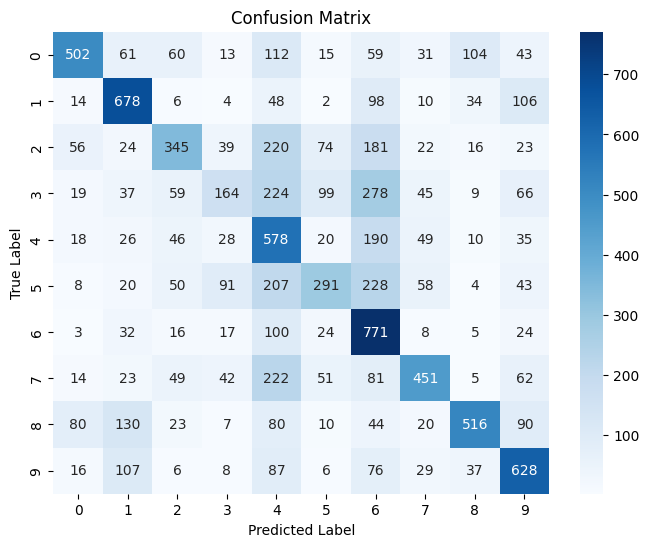

In [ ]:
find_knn4()